# Pre-Assignment for the Thesis

### Objective:

#### Your task would be to build a model for cell counting and train it using MoNuSeg dataset of 37 images with annotated cell boundaries. You can download the dataset here:

https://monuseg.grand-challenge.org/Data/

https://drive.google.com/file/d/1ZgqFJomqQGNnsx7w7QBzQQMVA16lbVCA/view

=> Perform a custom split on the dataset into training, validation, and test sets. Apply image patching to split the original images into smaller patches. Use a patch size between 128x128 and 256x256 for training.

=> Train a UNet model for segmenting the cells. Implement a simple method to count those individual cells on the predicted mask.

=> Develop a strategy on how to handle cells that are on the patch borders after segmentation. For example, you can count only the cells that touch the left and top borders of the patches.

#### NB: You are allowed to adapt codes from existing repos for your solution. Once again, please present visually as much intermediate results as possible in Google Collab.

### First Step: Bibliothecs and Moduls

In [1]:
# Installation of Bibliothecs
!pip install tensorflow
!pip install torch torchvision
!pip install scikit-image
!pip install albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 777.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [10]:
# Import Moduls
import os, zipfile, numpy as np, matplotlib.pyplot as plt
from skimage import io, color
from skimage.util import view_as_windows
from sklearn.model_selection import train_test_split
import albumentations as A

### Step 2: Data preparation

In [3]:
from google.colab import files

# Download the ZIP file
uploaded = files.upload()

# Extract ZIP file
import zipfile
import io

zip_file = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file]), 'r') as zip_ref:
    zip_ref.extractall('monuseg')

Saving MoNuSeg_2018_Training_Data.zip to MoNuSeg_2018_Training_Data.zip


In [7]:
# Imports for loading images and Maks and also for generate_mask_from_xml
!pip install xmltodict
!pip install imagecodecs
import xmltodict
import imagecodecs

### Step 3: Loading Images and Masks

In [11]:
# Importing the XML parser for processing the annotation files
import xml.etree.ElementTree as ET

# Help-function for generating a mask from XML annotation file
def generate_mask_from_xml(xml_path, mask_path, image_shape):
    try:
        # Reading and Parsing the XML-File
        tree = ET.parse(xml_path)
        root = tree.getroot()
        mask = np.zeros(image_shape, dtype=np.uint8) # Empty mask image with the same shape as the input image

        for region in root.findall(".//Region"):
            points = []
            for vertex in region.findall(".//Vertex"):
                # Exraction of coordinates of region
                x = int(float(vertex.get("X")))
                y = int(float(vertex.get("Y")))
                points.append((x, y))

            if points:
                # Create a binary mask based on the annotations
                from skimage.draw import polygon
                rr, cc = polygon([p[1] for p in points], [p[0] for p in points], mask.shape)
                mask[rr, cc] = 1

        io.imsave(mask_path, (mask * 255).astype(np.uint8)) # Save generated Mask
        return mask
    except Exception as e:
        print(f"Error when generating the mask for {xml_path}: {e}")
        return None

# Function for loading images and associated masks
def load_images_and_masks(image_dir, mask_dir, annotation_dir):
    images = []
    masks = []
    # Reading the file names in the respective directories
    image_files = os.listdir(image_dir)
    mask_files = os.listdir(mask_dir)
    annotation_files = os.listdir(annotation_dir)
    print("Available masks:", mask_files)  # Debugging

    for file_name in image_files:
        if file_name.endswith(".tif"): # Ensure that only image files are processed
            image_path = os.path.join(image_dir, file_name)
            mask_name = file_name.replace(".tif", "_mask.tif")
            mask_path = os.path.join(mask_dir, mask_name)
            xml_name = file_name.replace(".tif", ".xml")
            xml_path = os.path.join(annotation_dir, xml_name)

            image = imagecodecs.imread(image_path) # Reading Image
            if image.ndim == 3: # If it is an RGB image, I convert to gray scale
                image = color.rgb2gray(image)
            image = image.astype(np.float32)
            image = (image - image.min()) / (image.max() - image.min())

            # If the mask does not exist, I use my help-function to generate Mask from the XML file
            if not os.path.exists(mask_path):
                print(f"Mask not found for: {file_name}, expected: {mask_name}. Attempts to generate from {xml_name}")
                if os.path.exists(xml_path):
                    mask = generate_mask_from_xml(xml_path, mask_path, image.shape)
                else:
                    print(f"XML-File missing: {xml_name}, Mask cannot be generated.")
                    continue
            else:
                mask = io.imread(mask_path, as_gray=True)
                mask = (mask > 0.5).astype(np.uint8)

            # Save Image and Mask in the lists
            images.append(image)
            masks.append(mask)

    return np.array(images), np.array(masks)

# Definition of the data paths
image_dir = 'monuseg/MoNuSeg 2018 Training Data/Tissue Images'
mask_dir = 'monuseg/masks'
annotation_dir = 'monuseg/MoNuSeg 2018 Training Data/Annotations'

# If the mask directory does not exist, I create it
os.makedirs(mask_dir, exist_ok=True)

# Load Images and masks
images, masks = load_images_and_masks(image_dir, mask_dir, annotation_dir)
print("Number of loaded images:", len(images))
print("Number of loaded masks:", len(masks))

Available masks: []
Mask not found for: TCGA-G2-A2EK-01A-02-TSB.tif, expected: TCGA-G2-A2EK-01A-02-TSB_mask.tif. Attempts to generate from TCGA-G2-A2EK-01A-02-TSB.xml
Mask not found for: TCGA-A7-A13F-01Z-00-DX1.tif, expected: TCGA-A7-A13F-01Z-00-DX1_mask.tif. Attempts to generate from TCGA-A7-A13F-01Z-00-DX1.xml
Mask not found for: TCGA-B0-5698-01Z-00-DX1.tif, expected: TCGA-B0-5698-01Z-00-DX1_mask.tif. Attempts to generate from TCGA-B0-5698-01Z-00-DX1.xml
Mask not found for: TCGA-UZ-A9PN-01Z-00-DX1.tif, expected: TCGA-UZ-A9PN-01Z-00-DX1_mask.tif. Attempts to generate from TCGA-UZ-A9PN-01Z-00-DX1.xml
Mask not found for: TCGA-B0-5710-01Z-00-DX1.tif, expected: TCGA-B0-5710-01Z-00-DX1_mask.tif. Attempts to generate from TCGA-B0-5710-01Z-00-DX1.xml
Mask not found for: TCGA-G9-6362-01Z-00-DX1.tif, expected: TCGA-G9-6362-01Z-00-DX1_mask.tif. Attempts to generate from TCGA-G9-6362-01Z-00-DX1.xml
Mask not found for: TCGA-AR-A1AS-01Z-00-DX1.tif, expected: TCGA-AR-A1AS-01Z-00-DX1_mask.tif. Attem

### Step 4: Division of the data, Patches extraction and visualisation

Train: (25, 1000, 1000) (25, 1000, 1000)
Val: (6, 1000, 1000) (6, 1000, 1000)
Test: (6, 1000, 1000) (6, 1000, 1000)
y_train type: <class 'numpy.ndarray'>
y_val type: <class 'numpy.ndarray'>
y_test type: <class 'numpy.ndarray'>
y_train sample: [[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 1 1 1]
  [0 0 0 ... 1 1 1]
  [0 0 0 ... 1 1 1]]]
masks type: <class 'numpy.ndarray'>
masks contains None: False
X_train_patches shape: (1225, 128, 128)
y_train_patches shape: (1225, 128, 128)


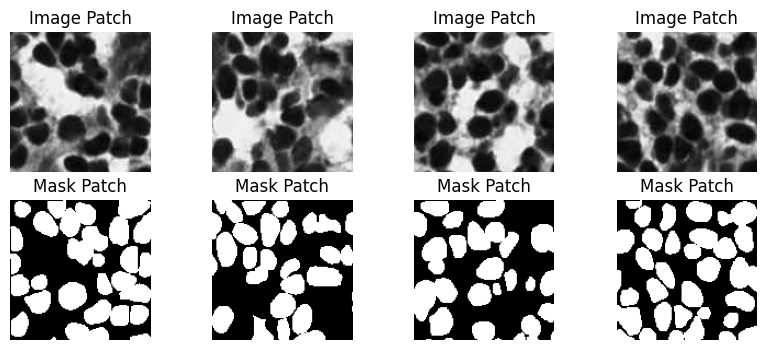

In [12]:
# Training, Validation and Test data
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#For Debugging
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("y_train type:", type(y_train))
print("y_val type:", type(y_val))
print("y_test type:", type(y_test))
print("y_train sample:", y_train[:2])  # Show the first two elemente
print("masks type:", type(masks))
print("masks contains None:", any(m is None for m in masks))

# Function to extract the Patch from images
def extract_patches_from_image(image, patch_size=128):
    h, w = image.shape
    patches = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
    return np.array(patches)

# Applying the patch extraction to all images and masks
def get_all_patches(images, patch_size):
    all_patches = []
    for img in images:
        patches = extract_patches_from_image(img, patch_size)
        all_patches.append(patches)
    return np.concatenate(all_patches, axis=0)

patch_size = 128
X_train_patches = get_all_patches(X_train, patch_size)
X_val_patches   = get_all_patches(X_val, patch_size)
X_test_patches  = get_all_patches(X_test, patch_size)
y_train_patches = get_all_patches(y_train, patch_size)
y_val_patches   = get_all_patches(y_val, patch_size)
y_test_patches  = get_all_patches(y_test, patch_size)

print("X_train_patches shape:", X_train_patches.shape)
print("y_train_patches shape:", y_train_patches.shape)

# Visualization of some image and mask patches
plt.figure(figsize=(10,4))
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train_patches[i], cmap='gray')
    plt.title("Image Patch")
    plt.axis('off')
    plt.subplot(2,4,i+5)
    plt.imshow(y_train_patches[i], cmap='gray')
    plt.title("Mask Patch")
    plt.axis('off')
plt.show()

### Step 5: UNet-Modell

In [13]:
# preparation for TensorFlow - Reshape & Normalization
# Since the images here ae gray scale images, I have added an additional dimension(1 Channel)
# Because, TensorFlow expect input with an additional dimension Channel (e.g. RGB has 3 Channels)
X_train_patches = X_train_patches[..., np.newaxis]
X_val_patches   = X_val_patches[..., np.newaxis]
X_test_patches  = X_test_patches[..., np.newaxis]

y_train_patches = y_train_patches[..., np.newaxis]
y_val_patches   = y_val_patches[..., np.newaxis]
y_test_patches  = y_test_patches[..., np.newaxis]

# New Training data ( should now be in the form (number, height, width, 1))
print("X_train_patches shape (after Reshape):", X_train_patches.shape)


# Definition of the UNet- Modell
from tensorflow.keras import layers, models

def unet(input_shape=(128, 128, 1)):
    inputs = layers.Input(input_shape) # Input layer for the model

    # Encoder (convolutional layers and Maxpooling for reducing the image size)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # central layer of the UNet
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)

    # Decoder (Upsampling)
    up1 = layers.UpSampling2D(size=(2, 2))(conv3) # Scaling Up the feature cards
    concat1 = layers.concatenate([conv2, up1], axis=-1) #Linking with encoder layer
    conv4 = layers.Conv2D(128, 3, activation='relu', padding='same')(concat1)
    conv4 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv4)

    up2 = layers.UpSampling2D(size=(2, 2))(conv4)
    concat2 = layers.concatenate([conv1, up2], axis=-1)
    conv5 = layers.Conv2D(64, 3, activation='relu', padding='same')(concat2)
    conv5 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv5)

     # Last layer to output the segmentation mask (1-channel with sigmoid for binary segmentation)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv5)

    model = models.Model(inputs, outputs)
    return model

# Initialisation of the modell
model = unet(input_shape=(patch_size, patch_size, 1))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

X_train_patches shape (after Reshape): (1225, 128, 128, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │            640 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d             │ (None, 64, 64, 256)    │              0 │ conv2d_5[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 64, 64, 384)    │              0 │ conv2d_3[0][0],        │
│                           │                        │                │ up_sampling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 64, 64, 128)    │        442,496 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_1           │ (None, 128, 128, 128)  │              0 │ conv2d_7[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 128, 128, 192)  │              0 │ conv2d_1[0][0],        │
│ (Concatenate)             │                        │                │ up_sampling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 128, 128, 64)   │        110,656 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)    

 Total params: 1,881,985 (7.18 MB)

 Trainable params: 1,881,985 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

### Step 6: Modelltraining and Process Visualisation

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1245s 16s/step - accuracy: 0.8890 - loss: 0.2563 - val_accuracy: 0.9070 - val_loss: 0.2275
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1278s 16s/step - accuracy: 0.8897 - loss: 0.2545 - val_accuracy: 0.8952 - val_loss: 0.2476
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1278s 16s/step - accuracy: 0.8908 - loss: 0.2527 - val_accuracy: 0.9096 - val_loss: 0.2160
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1371s 17s/step - accuracy: 0.8973 - loss: 0.2387 - val_accuracy: 0.9070 - val_loss: 0.2241
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1349s 17s/step - accuracy: 0.8986 - loss: 0.2362 - val_accuracy: 0.9057 - val_loss: 0.2275
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1262s 16s/step - accuracy: 0.9019 - loss: 0.2271 - val_accuracy: 0.9134 - val_loss: 0.2085
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1343s 17s/step - accuracy: 0.9033 - loss: 0.2247 - val_accuracy: 0.9027 - val_loss: 0.2315
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1310s 17s/step - accuracy: 0.9009 - loss: 0.2298 - val_accu

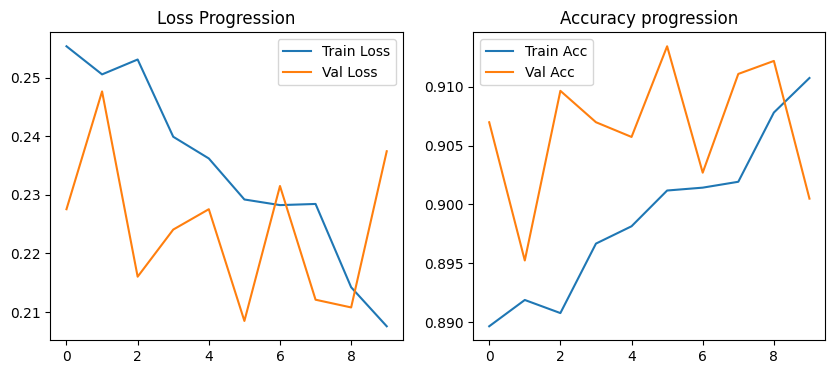

In [15]:
# Modelltraining
history = model.fit(X_train_patches, y_train_patches,
                    validation_data=(X_val_patches, y_val_patches),
                    epochs=10, batch_size=16)

# Visualisation of the training process
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Progression")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy progression")
plt.legend()
plt.show()


In [18]:
# Print the total achieved accuracy of the model
print("Total achieved accuracy:", history.history['accuracy'][-1])
print("Total achieved validation accuracy:", history.history['val_accuracy'][-1])
print("Total achieved loss:", history.history['loss'][-1])
print("Total achieved validation loss:", history.history['val_loss'][-1])


Total achieved accuracy: 0.9107403755187988
Total achieved validation accuracy: 0.9004948139190674
Total achieved loss: 0.2075665146112442
Total achieved validation loss: 0.23743540048599243


### Final Step: Segmentation, Cells counting and Visualisation

10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 8s/step


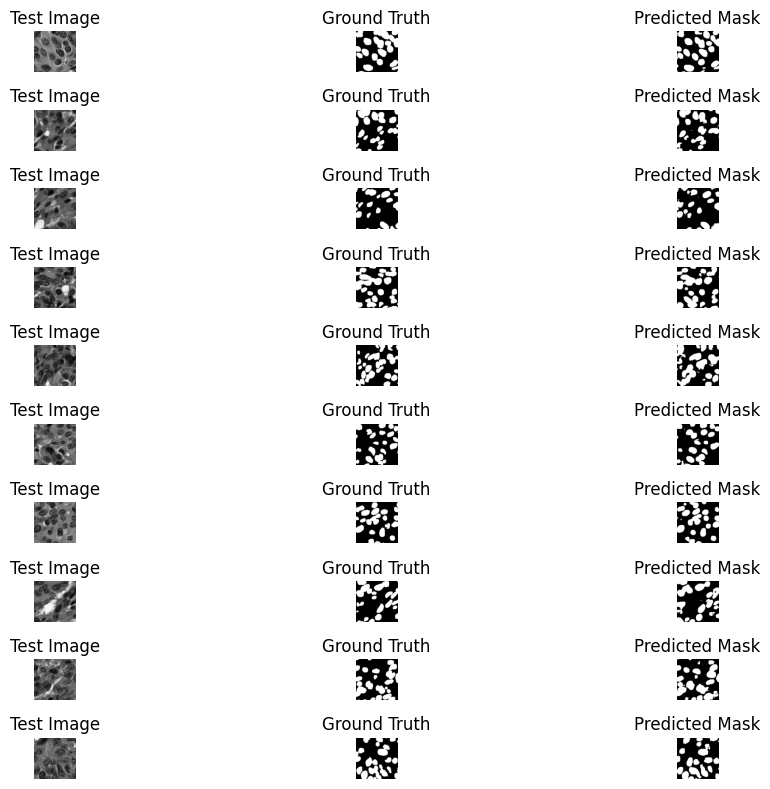

Patch 0: Counted Cells: 15


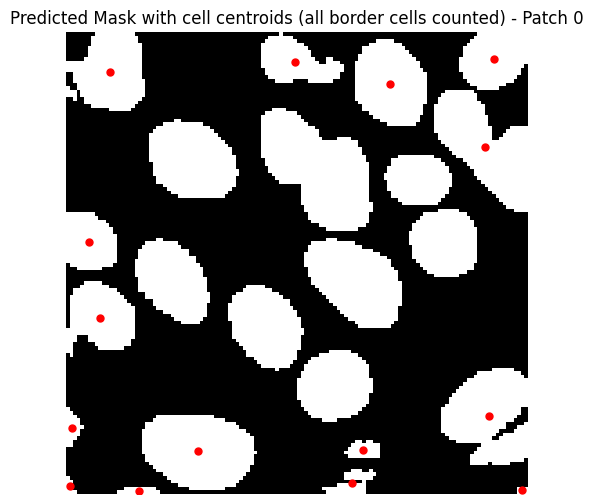

Patch 1: Counted Cells: 18


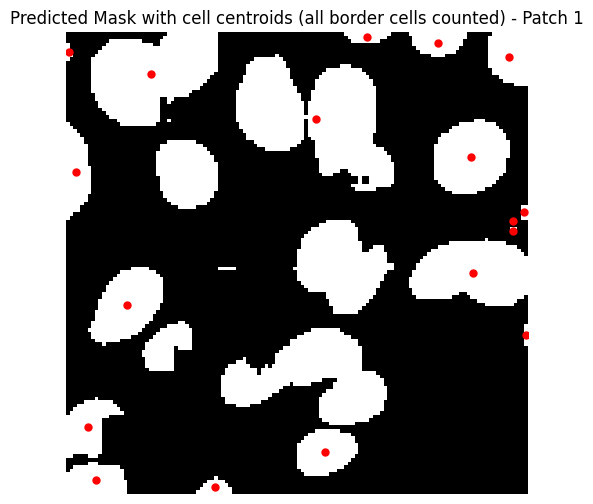

Patch 2: Counted Cells: 14


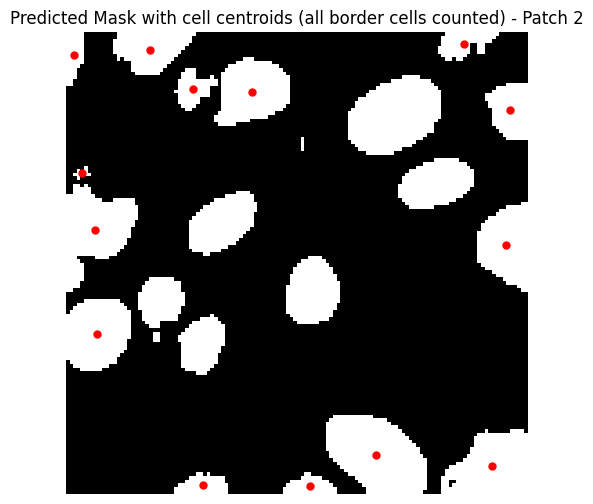

Patch 3: Counted Cells: 14


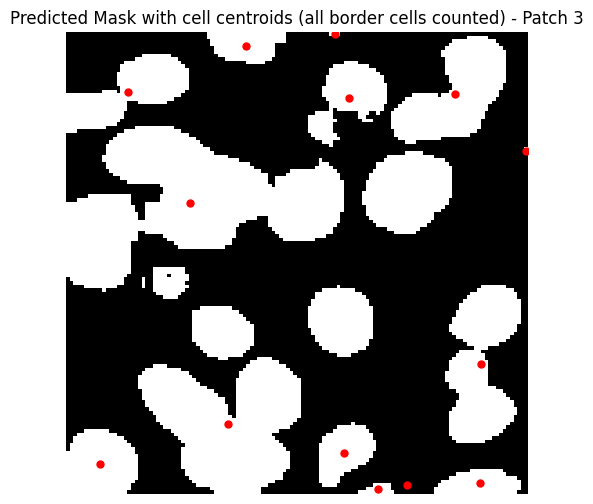

Patch 4: Counted Cells: 14


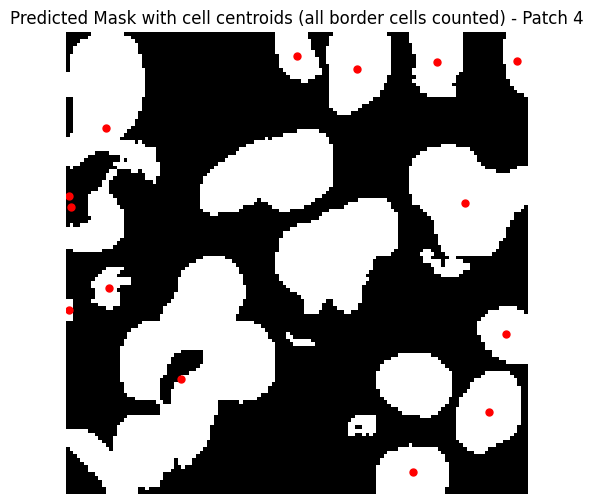

Patch 5: Counted Cells: 13


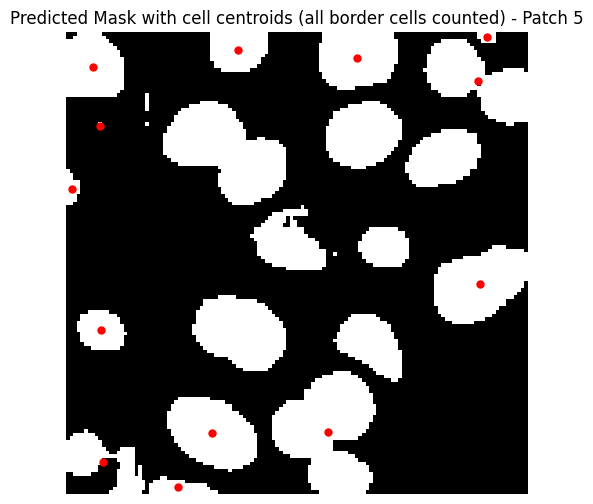

Patch 6: Counted Cells: 15


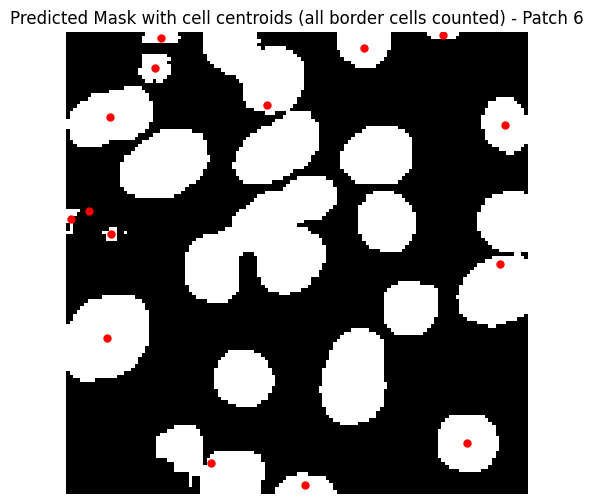

Patch 8: Counted Cells: 14


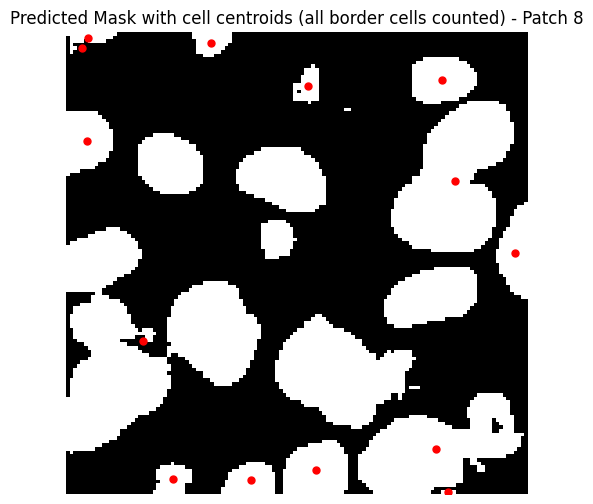

Patch 9: Counted Cells: 17


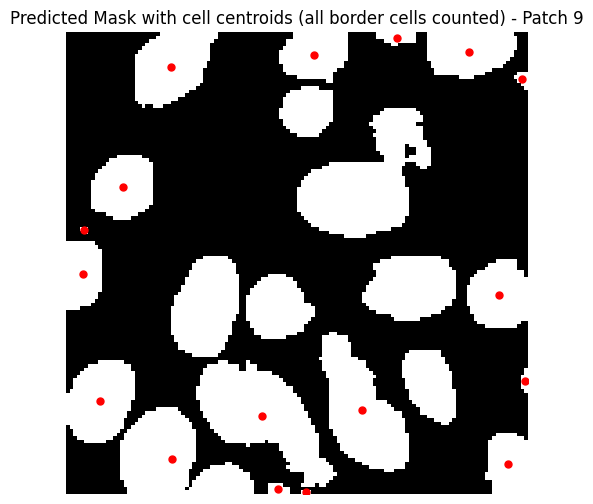

In [24]:
# Predictions on test patches and visualisation
preds = model.predict(X_test_patches)
preds_bin = (preds > 0.5).astype(np.uint8)

n = 10 # Number of examples to be visualized

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(n, 3, i*3+1)
    plt.imshow(X_test_patches[i].squeeze(), cmap='gray')
    plt.title("Test Image")
    plt.axis('off')

    plt.subplot(n, 3, i*3+2)
    plt.imshow(y_test_patches[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(n, 3, i*3+3)
    plt.imshow(preds_bin[i].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Cell counting function with treatment of patch boundaries
from skimage.measure import label, regionprops

def count_cells_in_patch(mask, border_threshold=10):
    """
    Counts the number of cells in a given mask patch,
    considering cells at all edges (top, bottom, left, right).

    Parameters:
        mask (numpy array): Binary mask with predicted cell segmentations.
        border_threshold (int): Threshold value for the boundary check.

    Returns:
        count (int):Number of counted cells.
        labeled_mask (numpy array): Mask with highlighted cell regions.
        centroids (list): List of cell centers as (y, x) coordinates.
    """

    labeled_mask = label(mask)
    regions = regionprops(labeled_mask)  # Extract properties of the regions

    count = 0  # Counter for cells
    centroids = []

    img_height, img_width = mask.shape  # Mask size

    for region in regions:
        minr, minc, maxr, maxc = region.bbox  # Bounding rectangle of the region

        # I check whether the cell is on one of the four edges
        if (minr <= border_threshold or  # Top
            minc <= border_threshold or  # Left
            maxr >= img_height - border_threshold or  # Botton
            maxc >= img_width - border_threshold ): # Right
            count += 1
            centroids.append(region.centroid)
        """ if minr <= border_threshold or minc <= border_threshold:
            count += 1
            centroids.append(region.centroid) """
    return count, labeled_mask, centroids

# Exemplary application to several test images
sample_idx = [0, 1, 2, 3, 4, 5, 6, 8, 9]
for idx in sample_idx:
    cell_count, labeled, centroids = count_cells_in_patch(preds_bin[idx].squeeze(), border_threshold=10)
    print(f"Patch {idx}: Counted Cells:", cell_count)

    # Visualisation of the cell mask with marked cell centers
    plt.figure(figsize=(6,6))
    plt.imshow(preds_bin[idx].squeeze(), cmap='gray')
    for cy, cx in centroids:
        plt.plot(cx, cy, 'ro', markersize=5)  # Marks cell centers with red dots
    plt.title(f"Predicted Mask with cell centroids (all border cells counted) - Patch {idx}")
    plt.axis('off')
    plt.show()